In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings("ignore")

## Import data

In [2]:
df = pd.read_csv('data.csv')
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


* id: Unique ID for the customer
* Gender: Gender of the customer
* Age: Age of the customer
* Driving_License: [0 : Customer does not have DL, 1 : Customer already has DL]
* Region_Code: Unique code for the region of the customer
* Previously_Insured: [1 : Customer already has Vehicle Insurance, 0 : Customer doesn't have Vehicle Insurance]
* Vehicle_Age: Age of the Vehicle
* Vehicle_Damage: [1 : Customer got his/her vehicle damaged in the past. 0 : Customer didn't get his/her vehicle damaged in the past.]
* Annual_Premium: The amount customer needs to pay as premium in the year
* Policy_Sales_Channel: Anonymized Code for the channel of outreaching to the customer ie. Different Agents, Over Mail, Over Phone, In Person, etc.
* Vintage: Number of Days, Customer has been associated with the company
* Response: [1 : Customer is interested, 0 : Customer is not interested

## EDA

In [3]:
df.shape

(381109, 12)

In [4]:
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 34.9 MB


In [6]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


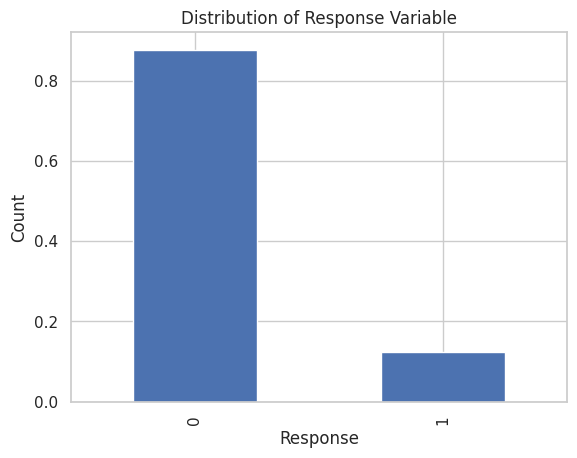

In [9]:
df['Response'].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribution of Response Variable')
plt.xlabel('Response')
plt.ylabel('Count')
plt.show()

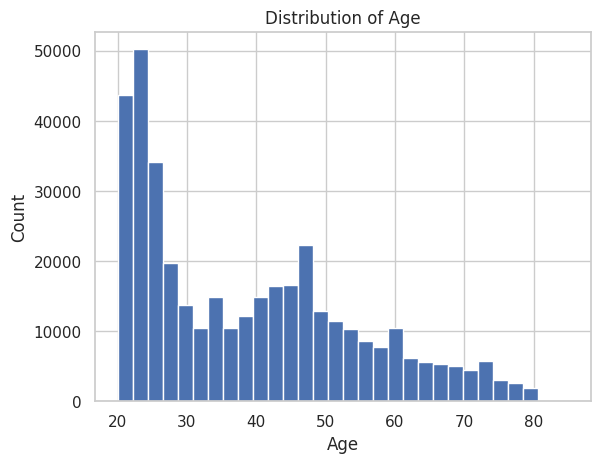

In [12]:
df['Age'].hist(bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

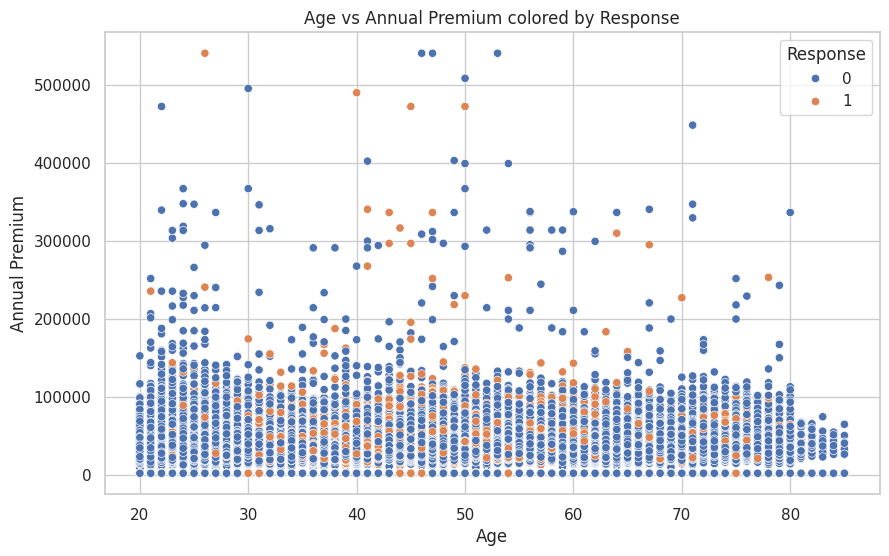

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Annual_Premium', hue='Response', data=df)
plt.title('Age vs Annual Premium colored by Response')
plt.xlabel('Age')
plt.ylabel('Annual Premium')
plt.legend(title='Response')
plt.show()

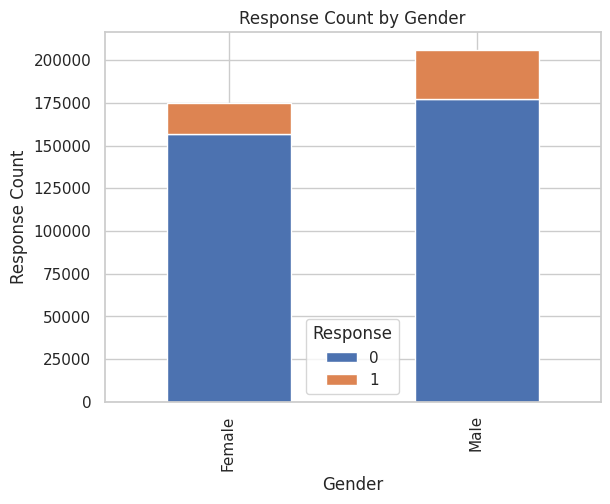

In [37]:
df.groupby(['Gender', 'Response']).size().unstack().plot(kind='bar', stacked=True)
plt.title('Response Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Response Count')
plt.legend(title='Response')
plt.show()

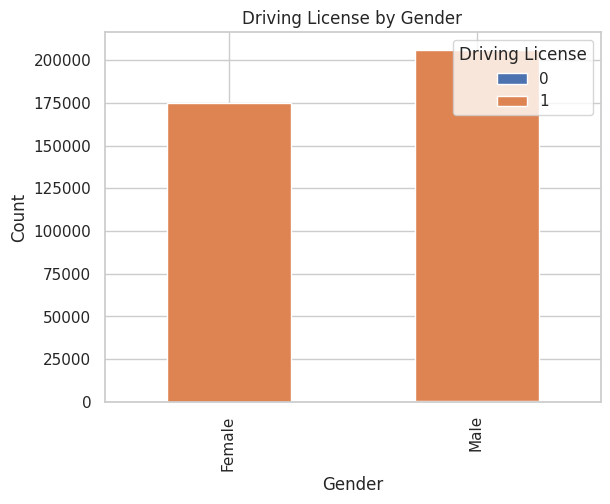

In [39]:
df.groupby('Gender')['Driving_License'].value_counts(normalize=False).unstack().plot(kind='bar', stacked=True)
plt.title('Driving License by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Driving License')
plt.show()

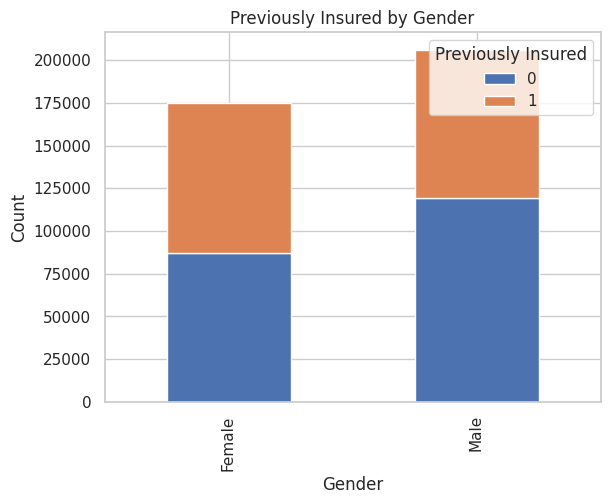

In [40]:
df.groupby('Gender')['Previously_Insured'].value_counts(normalize=False).unstack().plot(kind='bar', stacked=True)
plt.title('Previously Insured by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Previously Insured')
plt.show()

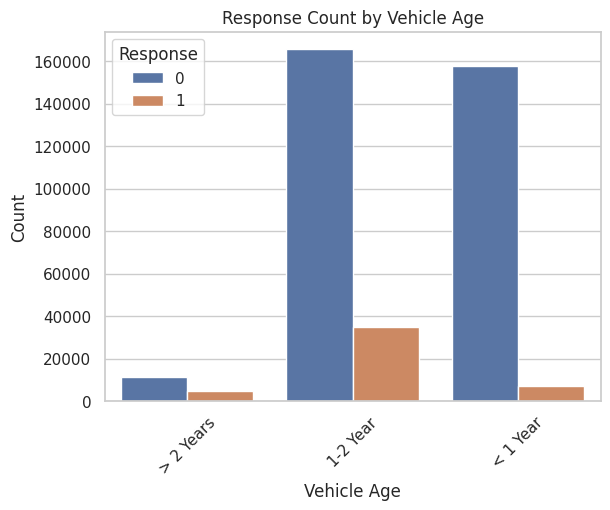

In [44]:
sns.countplot(x='Vehicle_Age', hue='Response', data=df)
plt.title('Response Count by Vehicle Age')
plt.xlabel('Vehicle Age')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.legend(title='Response')
plt.show()

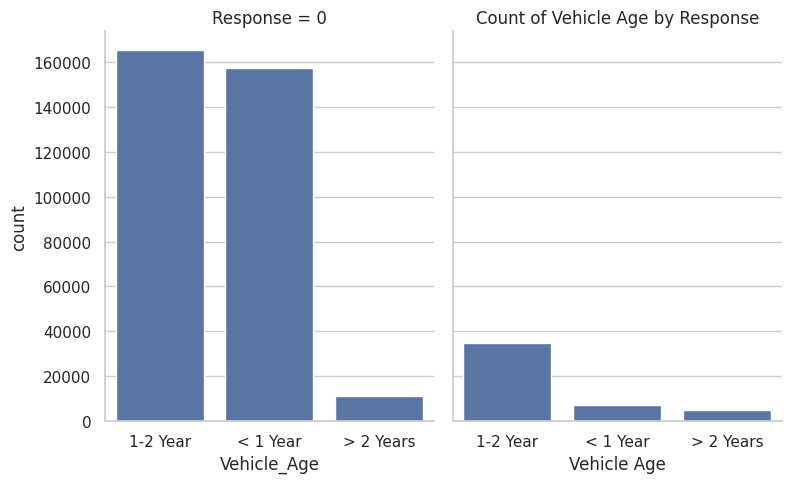

In [50]:
data = df.groupby(['Vehicle_Age', 'Response'])['id'].count().to_frame().rename(columns={'id':'count'}).reset_index()


sns.catplot(x='Vehicle_Age', y="count", col='Response', data=data, kind='bar', height=5, aspect=0.8)
plt.title('Count of Vehicle Age by Response')
plt.xlabel('Vehicle Age')
plt.ylabel('Count')
plt.show()

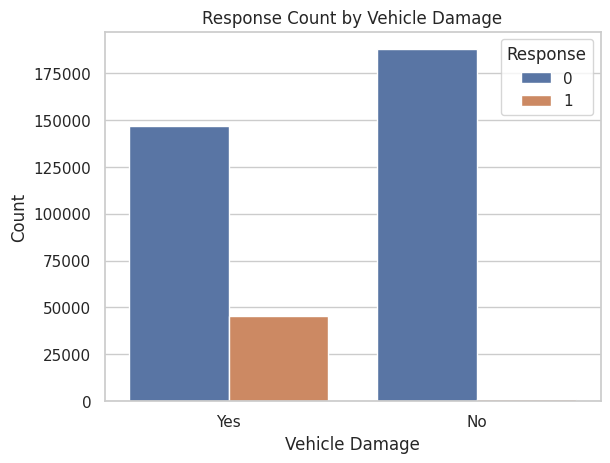

In [53]:
sns.countplot(x="Vehicle_Damage", hue='Response', data=df)
plt.title('Response Count by Vehicle Damage')
plt.xlabel('Vehicle Damage')
plt.ylabel('Count')
plt.legend(title='Response')
plt.show()

In [54]:
# checking stats for Annual_Premium
df['Annual_Premium'].describe()

count    381109.000000
mean      30564.389581
std       17213.155057
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max      540165.000000
Name: Annual_Premium, dtype: float64

Text(0.5, 0, 'Annual Premium')

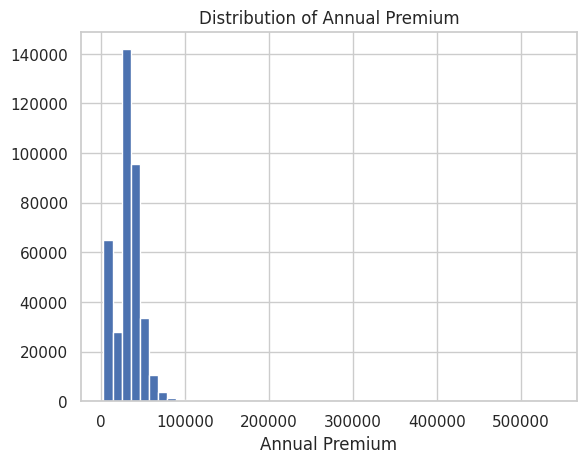

In [57]:
df['Annual_Premium'].hist(bins=50)
plt.title('Distribution of Annual Premium')
plt.xlabel('Annual Premium')

In [58]:
df[df['Annual_Premium']>200000]

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
1412,1413,Female,41,1,28.0,0,1-2 Year,Yes,267698.0,124.0,63,1
11319,11320,Female,50,1,46.0,1,1-2 Year,No,508073.0,26.0,192,0
13426,13427,Female,47,1,28.0,0,1-2 Year,Yes,301762.0,124.0,22,0
15024,15025,Female,32,1,28.0,0,1-2 Year,Yes,315565.0,155.0,150,0
25532,25533,Male,50,1,28.0,0,1-2 Year,Yes,229935.0,122.0,64,1
...,...,...,...,...,...,...,...,...,...,...,...,...
368263,368264,Female,25,1,28.0,1,< 1 Year,Yes,346982.0,124.0,74,0
371910,371911,Female,23,1,37.0,1,< 1 Year,No,235683.0,152.0,246,0
372492,372493,Male,46,1,18.0,0,1-2 Year,No,220581.0,26.0,210,0
373415,373416,Male,56,1,28.0,0,1-2 Year,No,337573.0,26.0,239,0


## data preprocessing

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 34.9 MB


In [ ]:
num_features = ['Age', 'Vintage', 'Annual_Premium']
cat_features = ['Gender', 'Driving_License', 'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage']
high_cardinality_features = ['Region_Code', 'Policy_Sales_Channel']

In [72]:
df_one_hot = pd.get_dummies(df[cat_features], drop_first=True).astype('int')
df_one_hot.head()

,Driving_License,Previously_Insured,Gender_Male,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,1,0,1,0,1,1
1,1,0,1,0,0,0
2,1,0,1,0,1,1
3,1,1,1,1,0,0
4,1,1,0,1,0,0


In [74]:
df_one_hot.rename(columns={'Vehicle_Age_< 1 Year':'Vehicle_Age_lt_1_Year', 'Vehicle_Age_> 2 Years':'Vehicle_Age_gt_2_Year'}, inplace=True)

In [79]:
final_df = pd.concat([df[num_features + high_cardinality_features + ['Response']], df_one_hot], axis=1)
final_df.head()

,Age,Vintage,Annual_Premium,Region_Code,Policy_Sales_Channel,Response,Driving_License,Previously_Insured,Gender_Male,Vehicle_Age_lt_1_Year,Vehicle_Age_gt_2_Year,Vehicle_Damage_Yes
0,44,217,40454.0,28.0,26.0,1,1,0,1,0,1,1
1,76,183,33536.0,3.0,26.0,0,1,0,1,0,0,0
2,47,27,38294.0,28.0,26.0,1,1,0,1,0,1,1
3,21,203,28619.0,11.0,152.0,0,1,1,1,1,0,0
4,29,39,27496.0,41.0,152.0,0,1,1,0,1,0,0


In [88]:
# train test split before scaling
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(final_df, test_size=0.2, random_state=42, stratify=final_df['Response'])

In [89]:
X_train = train_df.drop('Response', axis=1)
y_train = train_df['Response']

X_test = test_df.drop('Response', axis=1)
y_test = test_df['Response']

In [90]:
X_train.head()

,Age,Vintage,Annual_Premium,Region_Code,Policy_Sales_Channel,Driving_License,Previously_Insured,Gender_Male,Vehicle_Age_lt_1_Year,Vehicle_Age_gt_2_Year,Vehicle_Damage_Yes
274710,22,203,25455.0,40.0,152.0,1,0,1,1,0,1
216539,26,45,38393.0,8.0,26.0,1,1,0,1,0,0
78983,32,35,32118.0,28.0,122.0,1,0,0,1,0,1
218368,32,215,37711.0,37.0,152.0,1,0,1,1,0,1
307215,24,222,48706.0,28.0,156.0,1,0,0,1,0,1


In [92]:
from sklearn.preprocessing import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

ct = ColumnTransformer(transformers=[
    ('target_encoder', TargetEncoder(), high_cardinality_features),
    ('std_scaler', StandardScaler(), ['Age', 'Vintage']),
    ('mm_scaler', MinMaxScaler(), ['Annual_Premium'])
], remainder='passthrough')

pipe = Pipeline(steps=[
    ('preprocessor', ct),
    ('classifier', RandomForestClassifier(random_state=42))
])


pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('target_encoder', ...), ('std_scaler', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

In [104]:
# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

random_search = {'classifier__criterion': ['entropy', 'gini'],
               'classifier__max_depth': [2,3,4,5,6,7,10],
               'classifier__min_samples_leaf': [4, 6, 8],
               'classifier__min_samples_split': [5, 7,10],
               'classifier__n_estimators': [100, 200, 300, 400, 500]}

model = RandomizedSearchCV(estimator=pipe, param_distributions=random_search, n_iter=10, cv=5, verbose=1, random_state=101, n_jobs=-1)
model.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__criterion': ['entropy', 'gini'], 'classifier__max_depth': [2, 3, ...], 'classifier__min_samples_leaf': [4, 6, ...], 'classifier__min_samples_split': [5, 7, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-

In [105]:
model.best_params_

{'classifier__n_estimators': 400,
 'classifier__min_samples_split': 5,
 'classifier__min_samples_leaf': 8,
 'classifier__max_depth': 5,
 'classifier__criterion': 'gini'}

In [106]:
best_model = model.best_estimator_

In [107]:
# save best model
import pickle

filename = 'best_model.pkl'
pickle.dump(best_model, open(filename, 'wb'))

In [108]:
# loading back pickle file

rf_load = pickle.load(open(filename, 'rb'))

## Evaluate the model on the test set

In [109]:
from sklearn.metrics import classification_report

y_pred=rf_load.predict(X_test)
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.00      0.00      0.00      9342

    accuracy                           0.88     76222
   macro avg       0.44      0.50      0.47     76222
weighted avg       0.77      0.88      0.82     76222



ROC AUC Score: 0.85


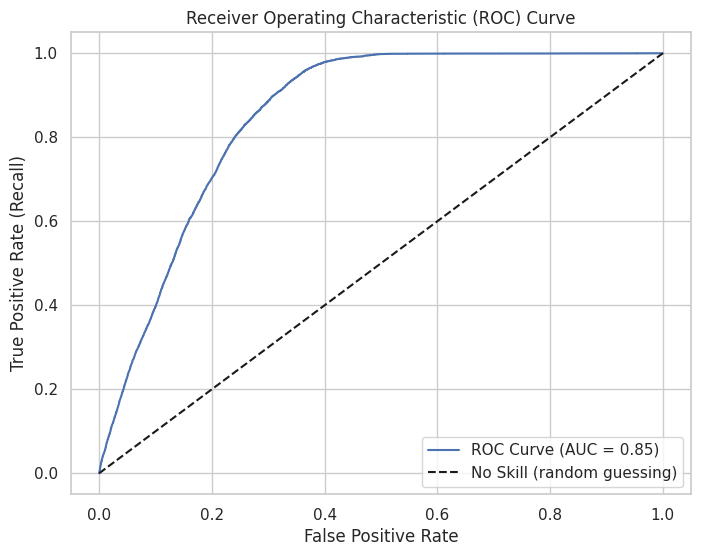

In [110]:
from sklearn.metrics import roc_auc_score, roc_curve

y_pred_proba = rf_load.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.2f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='No Skill (random guessing)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()